Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
df = pd.read_excel("/content/Mobile Sales Data.xlsx")

In [4]:
print(df.head())

   Transaction ID  Day  Month  Year  Day Name    Brand  Units Sold  \
0               1    9     10  2021       Sat   Xiaomi           6   
1               2    9     10  2021  Saturday     Vivo           6   
2               3    9     10  2021  Saturday     Vivo           8   
3               4   10     10  2021    Sunday   Xiaomi           5   
4               5   10     10  2021    Sunday  OnePlus           3   

   Price Per Unit       City Payment Method  Customer Ratings   Mobile Model  
0        10174.70   Ludhiana            UPI                 5  Redmi Note 10  
1        10565.19      Delhi    Credit Card                 3       Vivo Y51  
2        58527.58     Mumbai            UPI                 5        Vivo S1  
3        25563.98     Mumbai    Credit Card                 4          Mi 11  
4        48168.02  Gorakhpur           Cash                 5      OnePlus 9  


Check Dataset Information

In [5]:
#data types, missing values and column names
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    3835 non-null   int64  
 1   Day               3835 non-null   int64  
 2   Month             3835 non-null   int64  
 3   Year              3835 non-null   int64  
 4   Day Name          3835 non-null   object 
 5   Brand             3835 non-null   object 
 6   Units Sold        3835 non-null   int64  
 7   Price Per Unit    3835 non-null   float64
 8   City              3835 non-null   object 
 9   Payment Method    3835 non-null   object 
 10  Customer Ratings  3835 non-null   int64  
 11  Mobile Model      3835 non-null   object 
dtypes: float64(1), int64(6), object(5)
memory usage: 359.7+ KB
None


In [6]:
print(df.describe())

       Transaction ID          Day        Month         Year   Units Sold  \
count     3835.000000  3835.000000  3835.000000  3835.000000  3835.000000   
mean      1918.000000    15.703781     6.527249  2022.765319     4.993481   
std       1107.213469     8.822771     3.452030     0.917401     2.581122   
min          1.000000     1.000000     1.000000  2021.000000     1.000000   
25%        959.500000     8.000000     4.000000  2022.000000     3.000000   
50%       1918.000000    16.000000     7.000000  2023.000000     5.000000   
75%       2876.500000    23.000000    10.000000  2024.000000     7.000000   
max       3835.000000    31.000000    12.000000  2024.000000     9.000000   

       Price Per Unit  Customer Ratings  
count     3835.000000       3835.000000  
mean     40114.036816          3.693090  
std      17310.488427          1.325069  
min      10011.110000          1.000000  
25%      25617.405000          3.000000  
50%      40136.490000          4.000000  
75%      549

In [7]:
print(df.shape)

(3835, 12)


Check Missing Values

In [8]:
print(df.isnull().sum())

Transaction ID      0
Day                 0
Month               0
Year                0
Day Name            0
Brand               0
Units Sold          0
Price Per Unit      0
City                0
Payment Method      0
Customer Ratings    0
Mobile Model        0
dtype: int64


In [9]:
#Handle missing values
df = df.dropna()

Check Duplicate Rows

In [10]:
print(df.duplicated().sum())

0


In [11]:
df.drop_duplicates(inplace=True)

Exploratory Data Analysis (EDA)

Brand-wise sales

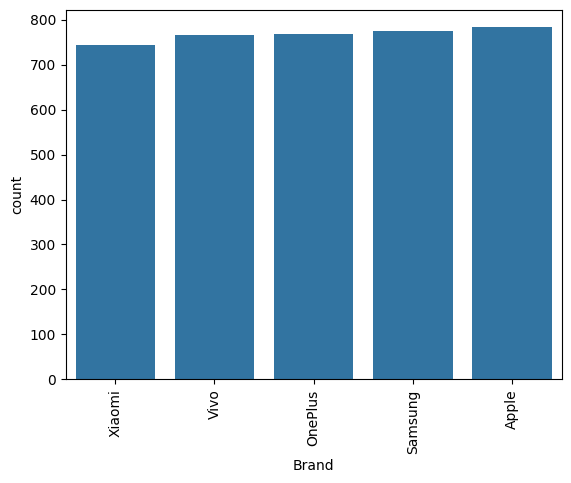

In [12]:
sns.countplot(x='Brand', data=df)
plt.xticks(rotation=90)
plt.show()

Price distribution

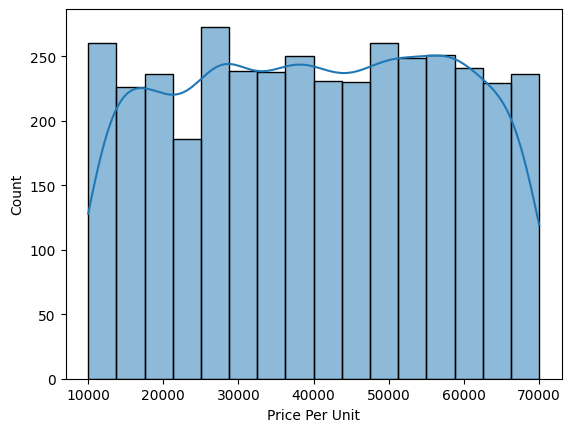

In [14]:
sns.histplot(df['Price Per Unit'], kde=True)
plt.show()

Correlation heatmap

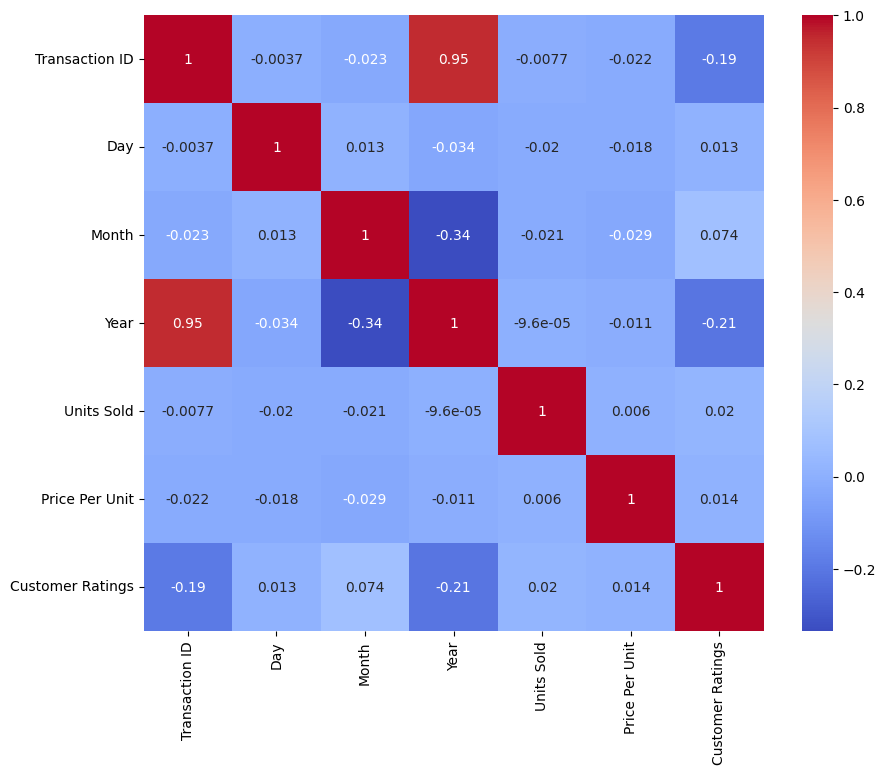

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
plt.show()

Feature Selection

In [17]:
X = df.drop('Units Sold', axis=1)
y = df['Units Sold']

Encode Categorical Variables

In [18]:
X = pd.get_dummies(X, drop_first=True)

Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Model

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Prediction

In [22]:
y_pred = model.predict(X_test)

Model Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.2604302477183835
MSE: 6.808224641460234
R2 Score: -0.041377279759255314


Feature Importance

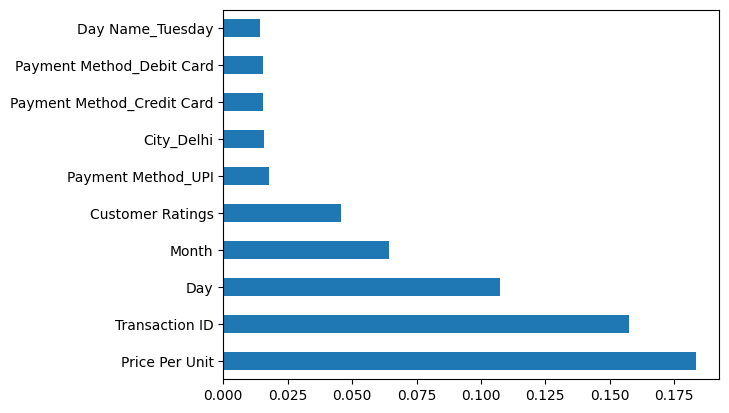

In [24]:
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.show()

Save Model

In [25]:
import joblib
joblib.dump(model, 'sales_model.pkl')

['sales_model.pkl']